# HF 배포본이 정말 최신인가 — 재배포가 필요한지 실측으로 가른다

**2026-09-02 · 이동원 (데이터 파트)**

---

## 팀원 질문

> **"HF 의 KRX 자료는 언제 최신으로 업데이트되나요?"**

짧은 답은 **"업데이트가 안 되는 것이 아니라, 지금은 더 늘 것이 없다"** 입니다.
배포본의 개발구간 상한이 `20210831` 이라 9/1 시세를 받아도 그 파일들은 한 줄도 바뀌지 않습니다.

그런데 이 답을 **짐작으로 내면 안 됩니다.** 8/31 에 올린 뒤로 이런 일이 있었기 때문입니다.

| 날짜 | 무슨 일 | 배포본이 바뀔 수 있나 |
|---|---|---|
| 09-01 15:19 | 종목코드가 여섯 자리라는 가정을 걷어냄 (조회에서 84종이 빠지고 있었다) | 행이 늘 수 있다 |
| 09-01 15:23 | `features/` 버그 3건 수정 — 결측 창 처리 · `true_range` | **피처 값이 바뀔 수 있다** |
| 09-01 17:02 | 피처 추가 (`indicators.py` · `returns.py`) | 값이 바뀔 수 있다 |
| 09-01 20:43 | 액면분할로 끊긴 가격을 잇는 함수 추가 (PR #53) | **값이 바뀔 수 있다** |

특히 마지막 것이 걸립니다. 액면분할 조정은 **값만 바꾸고 행 수는 그대로**입니다.
행 수를 세는 검사로는 절대 못 잡습니다.

이 노트북은 **"정말 안 바뀌었는가"를 전량 대조로 확인한 기록**입니다.

---

## 0. 준비

검증 로직은 `scripts/verify_hf_dataset.py` 에 있습니다. 노트북은 그걸 불러 쓰고,
**왜 그렇게 재는지 설명하고 결과를 그리는 데** 집중합니다. 같은 코드를 두 곳에 두면
언젠가 갈라지기 때문입니다.

In [1]:
import importlib.util
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# 프로젝트 루트를 찾아 올라간다 (노트북이 어디서 열리든 같게 동작하도록)
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "scripts" / "verify_hf_dataset.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

# 한글이 깨지면 그래프를 읽을 수 없다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

spec = importlib.util.spec_from_file_location(
    "verify_hf_dataset", ROOT / "scripts" / "verify_hf_dataset.py")
V = importlib.util.module_from_spec(spec)
spec.loader.exec_module(V)

SNAP = ROOT / "data" / "outbox" / "hf_snapshot"
print(f"프로젝트 루트 : {ROOT}")
print(f"HF 사본       : {SNAP}  (있음: {SNAP.exists()})")
print(f"DB(읽기전용)  : {V.db_path()}")

프로젝트 루트 : C:\Users\kik32\workspace\EST-Camp-AI-Quant\team_project\Alpha_Stack\.claude\worktrees\hf-krx-refresh
HF 사본       : C:\Users\kik32\workspace\EST-Camp-AI-Quant\team_project\Alpha_Stack\.claude\worktrees\hf-krx-refresh\data\outbox\hf_snapshot  (있음: True)
DB(읽기전용)  : C:/Users/kik32/workspace/EST-Camp-AI-Quant/team_project/Alpha_Stack/data/krx_cache.db


---

## 1. 어떻게 재기로 했나 — 두 번 막히고 나서

### 첫 계획: 다시 만들어서 SHA 를 대조한다

가장 단순한 방법입니다. 반출본을 다시 만들어 `MANIFEST.json` 의 SHA-256 과 비교하면 됩니다.
**그런데 두 군데서 막혔습니다.**

#### 막힘 ① — 재생성은 DB 에 쓴다

`export_team_dataset.py` 를 돌리자 3.8초 만에 멈췄습니다.

```
index_series() → krx_index.series() → init_db() → migrate_path()
MigrationError: DB 가 코드보다 최신이다 (DB v7 > 코드 v6)
```

확인만 하려던 작업이 **스키마 마이그레이션을 실행하려** 했습니다.
게다가 공유 DB 는 다른 세션이 이미 v7 로 올린 상태였습니다.

#### 막힘 ② — SHA 는 한쪽으로만 강한 증거다

이게 더 중요합니다. 큰 벌 parquet 은 이렇게 뽑습니다.

```sql
SELECT * FROM daily_price WHERE bas_dd <= ?     -- ORDER BY 가 없다
```

**행 순서가 보장되지 않습니다.** 자료가 한 글자도 안 바뀌어도 순서만 달라지면 SHA 는 달라집니다.

| SHA 비교 결과 | 무엇을 알 수 있나 |
|---|---|
| **같다** | 확실히 같다 (강한 증거) |
| **다르다** | 자료가 달라졌을 수도, 순서·표기만 달라졌을 수도 (약한 증거) |

우리가 알고 싶은 건 "달라졌는가" 인데, 하필 **다를 때 아무것도 못 말하는** 도구였습니다.

### 그래서 바꾼 계획: HF 파일을 받아 값으로 대조한다

| | 재생성 + SHA | HF 파일 ↔ DB 값 대조 |
|---|---|---|
| DB 쓰기 | 마이그레이션을 탄다 | **`mode=ro` 로만 연다** |
| 다른 세션 | v7 머지를 기다려야 한다 | 기다릴 필요 없다 |
| 순서·표기 문제 | 걸린다 | **정렬 후 값을 보므로 해당 없음** |
| 결론의 강도 | 파일이 같은가 | **어느 칸의 몇 행이 다른가** |

---

## 2. HF 에 지금 무엇이 있나

먼저 **대조의 전제**를 세웁니다. 내려받은 파일이 정말 HF 의 그 파일인지 확인하지 않으면,
그 뒤의 모든 비교가 무엇을 비교한 것인지 알 수 없습니다.

In [2]:
manifest = json.loads((SNAP / "MANIFEST.json").read_text(encoding="utf-8"))

print(f"생성 시각     : {manifest['generated_at']}")
print(f"개발구간 상한 : {manifest['dev_end']}   (봉인 시작 {manifest['holdout_start']})")
print(f"예측 지평     : {manifest['horizon']}거래일 · 밴드 {manifest['band']}")
print()

files = pd.DataFrame(manifest["files"])[["path", "rows", "size_mb", "sha256"]]
files["sha256"] = files["sha256"].str[:12]
files["columns"] = [len(f["columns"]) for f in manifest["files"]]
display(files[["path", "rows", "columns", "size_mb", "sha256"]])

ok = V.verify_manifest(SNAP, manifest)
print(f"\n내려받은 파일이 MANIFEST 와 맞는가 → {ok}")

생성 시각     : 2026-08-31T17:23:11+09:00
개발구간 상한 : 20210831   (봉인 시작 20210901)
예측 지평     : 5거래일 · 밴드 {'index': 0.01, 'stock': 0.02}



,path,rows,columns,size_mb,sha256
0,index_all_dev.csv,135879,12,14.307,43646518e0d1
1,index_kospi200_dev.csv,2880,13,0.328,e0a0045ff015
2,features_labels_kospi200_dev.csv,2815,37,1.478,51c3ccd65e55
3,stocks_sample30_raw_dev.csv,63746,16,7.710,4c5e96b25cf7
4,stocks_sample30_train_dev.csv,58791,16,7.158,7583794e3fa0
5,features_labels_stocks30_dev.csv,56706,40,27.173,a120831c9715
6,daily_price_dev.parquet,5989308,15,142.077,d2e2ee8f6fb7
7,index_price_dev.parquet,135879,12,5.688,90dcc078ae8e


  ✅ MANIFEST 의 SHA-256 8건 전부 일치

내려받은 파일이 MANIFEST 와 맞는가 → True


> **`generated_at` 이 17:23:11 KST 인데 HF 커밋은 17:29:56 KST 입니다.**
> 파일을 만들고 6분 뒤에 올린 것이라 자연스럽습니다. 다만 반출 스크립트가 커밋된 시각은
> **17:34 KST** 로, 배포보다 5분 늦습니다. 즉 배포에 쓴 코드가 그 커밋과 글자까지 같은지는
> 확인할 수 없습니다. **이건 못 잰 것으로 남깁니다.**

---

## 3. 원시 자료 — 599만 행을 칸별로 맞춰본다

`daily_price` 는 개발구간만 599만 행입니다. 양쪽을 통째로 메모리에 올리면 여유를 넘겨서
(병행 세션도 돌고 있었습니다) **연도별로 끊어서** 비교했습니다.

행 수만 세지 않는다는 점이 중요합니다. **15칸을 전부 값으로 맞춰봅니다.**

In [3]:
import pyarrow.parquet as pq

DEV_END = manifest["dev_end"]
rows_by_year, same_by_year = {}, {}

for year in range(2010, 2022):
    lo, hi = f"{year}0101", min(f"{year}1231", DEV_END)
    if lo > DEV_END:
        break
    hf = pq.read_table(SNAP / "full/daily_price_dev.parquet",
                       filters=[("bas_dd", ">=", lo), ("bas_dd", "<=", hi)]).to_pandas()
    with V.ro_connect() as conn:
        db = pd.read_sql_query(
            "SELECT * FROM daily_price WHERE bas_dd BETWEEN ? AND ?",
            conn, params=(lo, hi))
    hf_s = hf.sort_values(["bas_dd", "code"], kind="mergesort").reset_index(drop=True)
    db_s = db.sort_values(["bas_dd", "code"], kind="mergesort").reset_index(drop=True)
    다른칸 = [c for c in hf_s.columns if V.compare_column(hf_s[c], db_s[c]) is not None]
    rows_by_year[year] = len(hf)
    same_by_year[year] = not 다른칸
    print(f"  {year}년  {len(hf):>7,}행 × {len(hf.columns)}칸  "
          + ("✅ 전부 같다" if not 다른칸 else f"🔴 다른 칸 {다른칸}"))
    del hf, db, hf_s, db_s

print(f"\n합계 {sum(rows_by_year.values()):,}행 · "
      f"모든 연도 일치: {all(same_by_year.values())}")

  2010년  489,223행 × 15칸  ✅ 전부 같다


  2011년  487,308행 × 15칸  ✅ 전부 같다


  2012년  485,169행 × 15칸  ✅ 전부 같다


  2013년  474,866행 × 15칸  ✅ 전부 같다


  2014년  470,960행 × 15칸  ✅ 전부 같다


...

  2017년  515,693행 × 15칸  ✅ 전부 같다


  2018년  530,999행 × 15칸  ✅ 전부 같다


  2019년  555,287행 × 15칸  ✅ 전부 같다


  2020년  580,252행 × 15칸  ✅ 전부 같다


  2021년  401,866행 × 15칸  ✅ 전부 같다

합계 5,989,308행 · 모든 연도 일치: True


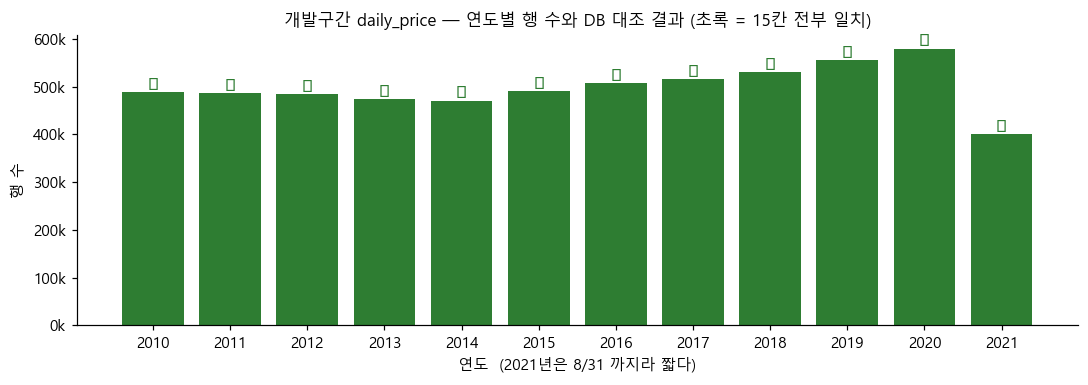

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.6))
years = list(rows_by_year)
colors = ["#2E7D32" if same_by_year[y] else "#C62828" for y in years]
bars = ax.bar([str(y) for y in years], [rows_by_year[y] for y in years], color=colors)
ax.set_title("개발구간 daily_price — 연도별 행 수와 DB 대조 결과 (초록 = 15칸 전부 일치)",
             fontsize=11)
ax.set_ylabel("행 수")
ax.set_xlabel("연도  (2021년은 8/31 까지라 짧다)")
ax.yaxis.set_major_formatter(lambda x, p: f"{x/1e3:.0f}k")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() * 1.01,
            "✓", ha="center", fontsize=11, color="#2E7D32")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---

## 4. 함정 — CSV 로 받으면 값이 미세하게 달라진다

`full/*.parquet` 은 DB 와 **완전히 일치**했습니다. 그런데 같은 자료를 담은
`small/index_all_dev.csv` 에서는 `market_cap` 388행이 어긋났습니다.

같은 SQL 에서 나온 자료인데 왜 한쪽만 다를까요.

**가르는 방법이 있습니다 — HF 자기 파일끼리 비교하는 것입니다.**
`index_price_dev.parquet` 과 `index_all_dev.csv` 는 **같은 실행에서 같은 SQL 로 뽑은 같은 자료**입니다.
그러니 이 둘이 서로 다르면, 그 차이는 DB 가 변해서가 아니라 **CSV 로 쓰고 읽는 길에서 생긴 것**입니다.

In [5]:
par = pd.read_parquet(SNAP / "full/index_price_dev.parquet")
csv = pd.read_csv(SNAP / "small/index_all_dev.csv",
                  dtype={"bas_dd": str, "index_name": str, "index_class": str})
keys = ["bas_dd", "index_name"]
par = par.sort_values(keys, kind="mergesort").reset_index(drop=True)
csv = csv.sort_values(keys, kind="mergesort").reset_index(drop=True)

a = par["market_cap"].to_numpy(dtype="float64")
b = csv["market_cap"].to_numpy(dtype="float64")
다름 = ~((a == b) | (np.isnan(a) & np.isnan(b)))
idx = np.where(다름)[0]

절대차 = np.abs(a[idx] - b[idx])
ulp배수 = 절대차 / np.spacing(np.abs(a[idx]))
상대차 = 절대차 / np.abs(a[idx])

print(f"HF 의 parquet 과 HF 의 csv 가 서로 다른 행 : {len(idx):,} / {len(a):,} "
      f"({len(idx)/len(a):.2%})")
print(f"  절대차   최대 {절대차.max():.4g}")
print(f"  ULP 배수 최대 {ulp배수.max():.2f}  (1 이면 float64 가 표현할 수 있는 최소 간격)")
print(f"  상대차   최대 {상대차.max():.3e}  (float64 한계 {np.finfo(float).eps:.3e})")
print()
for i in idx[:3]:
    print(f"  {par.at[i, 'bas_dd']} {par.at[i, 'index_name']:16s}"
          f" parquet={a[i]!r}  csv={b[i]!r}")

HF 의 parquet 과 HF 의 csv 가 서로 다른 행 : 388 / 135,879 (0.29%)
  절대차   최대 0.25
  ULP 배수 최대 1.00  (1 이면 float64 가 표현할 수 있는 최소 간격)
  상대차   최대 1.385e-16  (float64 한계 2.220e-16)

  20201127 코스피              parquet=1807866930879163.0  csv=1807866930879163.2
  20201127 코스피 (외국주포함)      parquet=1808171429285453.0  csv=1808171429285452.8
  20201201 코스피 (외국주포함)      parquet=1809494578238153.0  csv=1809494578238152.8


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


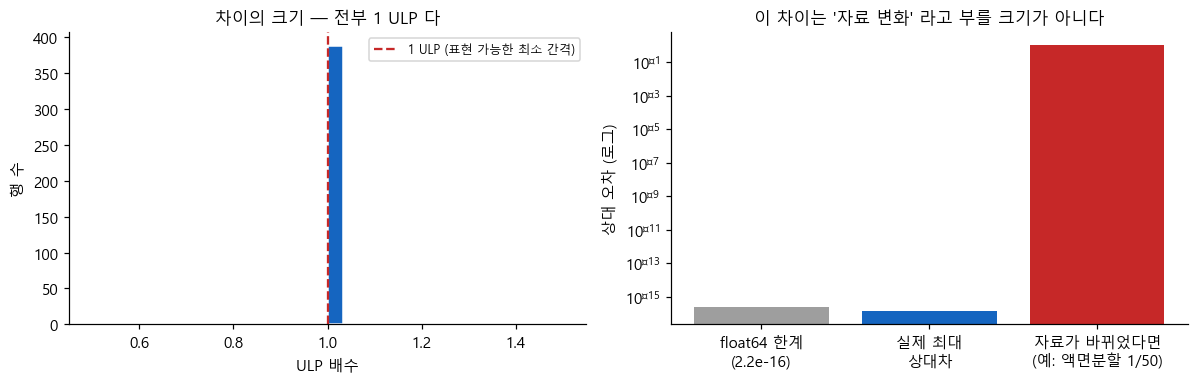

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(ulp배수, bins=30, color="#1565C0", edgecolor="white")
axes[0].axvline(1.0, color="#C62828", ls="--", lw=1.5, label="1 ULP (표현 가능한 최소 간격)")
axes[0].set_title("차이의 크기 — 전부 1 ULP 다", fontsize=11)
axes[0].set_xlabel("ULP 배수")
axes[0].set_ylabel("행 수")
axes[0].legend(fontsize=8)

축 = ["float64 한계\n(2.2e-16)", "실제 최대\n상대차", "자료가 바뀌었다면\n(예: 액면분할 1/50)"]
값 = [np.finfo(float).eps, 상대차.max(), 0.98]
axes[1].bar(축, 값, color=["#9E9E9E", "#1565C0", "#C62828"])
axes[1].set_yscale("log")
axes[1].set_title("이 차이는 '자료 변화' 라고 부를 크기가 아니다", fontsize=11)
axes[1].set_ylabel("상대 오차 (로그)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**전부 정확히 1 ULP 입니다.** `market_cap` 이 1.8경(10¹⁵) 규모라 float64 의 유효숫자를
넘어서고, CSV 로 적었다 읽으면 끝자리가 흔들립니다.

독립 근거를 하나 더 댑니다 — **지금 parquet 값을 CSV 로 썼다 읽으면 똑같이 깨지는지** 봅니다.
같은 388행이 깨진다면 원인이 CSV 왕복이라는 것이 확정됩니다.

In [7]:
tmp = SNAP.parent / "_roundtrip_check.csv"
par[["bas_dd", "index_name", "market_cap"]].to_csv(tmp, index=False, encoding="utf-8-sig")
back = pd.read_csv(tmp, dtype={"bas_dd": str, "index_name": str})
c = back["market_cap"].to_numpy(dtype="float64")
깨진 = int((~((a == c) | (np.isnan(a) & np.isnan(c)))).sum())
tmp.unlink(missing_ok=True)

print(f"parquet 값을 CSV 로 왕복시켰더니 달라진 행 : {깨진:,}")
print(f"HF 에서 관측된 차이                        : {len(idx):,}")
print(f"→ {'같다. 원인은 CSV 왕복이 맞다.' if 깨진 == len(idx) else '다르다. 다른 원인이 있다.'}")

parquet 값을 CSV 로 왕복시켰더니 달라진 행 : 388
HF 에서 관측된 차이                        : 388
→ 같다. 원인은 CSV 왕복이 맞다.


### 같은 일이 `sector` 에서도 일어납니다

`stocks_sample30_raw_dev.csv` 의 `sector` 는 32,226행(50.6%)이 어긋났습니다. 값을 보면:

| | 값 | 행 수 |
|---|---|---|
| DB | **빈 문자열** `""` | 32,226 |
| HF CSV | `NaN` | 32,226 |

나머지 값의 분포는 완전히 같습니다(우량기업부 8,772 · 벤처기업부 8,517 …).
KOSPI 종목은 소속부가 없어 DB 에 빈 문자열로 들어 있는데, **CSV 를 거치면 결측이 됩니다.**

> 🔴 **팀원께**: 이래서 **CSV 보다 parquet 을 쓰시는 게 좋습니다.**
> CSV 를 쓰셔야 한다면 `df["sector"].fillna("")` 로 맞춰 주세요.

---

## 5. 가장 어려운 부분 — 코드가 바뀌어서 값이 달라졌나

원시 자료가 그대로라는 건 확인했습니다. 그런데 **피처·라벨은 계산해서 만드는 것**이라,
계산하는 코드가 바뀌면 같은 원본에서도 다른 값이 나옵니다.
그리고 9/1 에 `features/` 버그 3건이 실제로 수정됐습니다.

### 처음엔 이렇게 쟀는데, 틀린 방법이었습니다

HF 의 입력 파일에 **지금 코드**를 걸어 HF 의 출력과 비교했습니다. 결과는 이랬습니다.

```
hv_20         53,964행 (95.16%) 다름
bb_bandwidth  39,686행 (69.99%) 다름
```

**"코드가 바꿨다"고 결론 내릴 뻔했습니다.** 그런데 값을 들여다보니:

```
HF = 0.0567699457082742      ← 유효숫자 15자리
재계산 = 0.05676994570827423  ← 16자리
```

**대조가 비대칭이었습니다.**

| | 거친 길 |
|---|---|
| HF 의 값 | 계산 → **CSV 쓰기** → **CSV 읽기** |
| 제 재계산 | **CSV 읽기** → 계산 |

게다가 입력 자체도 CSV 왕복본이라, `hv_20`(표준편차)·`bb_bandwidth`(표준편차/평균) 처럼
**값을 빼는 계산**은 그 흔들림을 몇십 배로 키웁니다. 코드 영향과 표기 오차가 뒤섞여
무엇 때문인지 가를 수 없는 대조였습니다.

### 변수를 하나만 남기는 방법

**같은 입력에 8/31 당시 코드와 지금 코드를 각각 걸어** 비교하면 됩니다.
양쪽 다 같은 CSV 왕복본을 쓰므로 표기 오차가 상쇄되고, **변수는 코드 하나만 남습니다.**

In [8]:
import subprocess

BASELINE = "5a52655"        # 8/31 17:34 KST — 반출 스크립트를 만든 커밋

diff = subprocess.run(
    ["git", "diff", "--stat", BASELINE, "HEAD", "--",
     "features/", "evaluation/", "supply/", "scripts/export_team_dataset.py"],
    cwd=ROOT, capture_output=True, text=True, encoding="utf-8").stdout
print("8/31 이후 반출 경로에서 바뀐 파일\n")
print(diff or "  (없음)")

8/31 이후 반출 경로에서 바뀐 파일

 features/indicators.py | 66 +++++++++++++++++++++++++++++++++++++++++++++++++-
 features/returns.py    | 61 ++++++++++++++++++++++++++++++++++++++++++++++
 features/volatility.py | 10 ++++++++
 features/volume.py     |  9 ++++++-
 4 files changed, 144 insertions(+), 2 deletions(-)



**`supply/` 와 `evaluation/`, 그리고 반출 스크립트 자체는 한 줄도 바뀌지 않았습니다.**
바뀐 것은 `features/` 뿐입니다. 그러면 대조의 변수가 정확히 그것 하나로 좁혀집니다.

이제 두 시점의 코드로 같은 입력을 계산해 비교합니다.

In [9]:
same = V.compare_code_effect(BASELINE, SNAP, DEV_END)
print(f"\n8/31 코드와 지금 코드의 결과가 같은가 → {same}")


[5] 코드 영향 — 5a52655 ↔ 지금


  5a52655 트리를 풀었다 (5.1 MB)



── kospi200 (옛 코드 ↔ 지금 코드) ──
  ✅ 2,815행 × 37칸 — 완전히 같다

── stocks30 (옛 코드 ↔ 지금 코드) ──
  ✅ 56,706행 × 40칸 — 완전히 같다

8/31 코드와 지금 코드의 결과가 같은가 → True


**비트 단위까지 동일합니다.**

수정된 내용이 *"창 안에 결측이 있으면 결과를 결측으로 한다"* 였는데,
이 표본 구간에는 해당 결측이 없어 값이 달라지지 않았습니다.
버그 수정은 옳았지만 **이 자료에서는 발동하지 않았습니다.**

### 액면분할(PR #53)은 어떻게 됐나

첫 가설의 주인공이었습니다. 확인 결과 **아직 어디에도 반영되지 않았습니다.**
PR 본문이 직접 이렇게 적고 있습니다.

> **아직 적용하지 않았습니다 — 파트 경계**
> 수익률을 계산하는 자리가 4곳이고 전부 아직 조정을 반영하지 않습니다.
> `scripts/export_team_dataset.py::forward_returns_aligned` … **함수를 만들고 검증까지만** 했습니다.

실제로 `common/corporate_actions.py` 를 부르는 곳은 `supply/training.py` 와 진단 스크립트뿐이고,
`supply/` 는 8/31 이후 무변경입니다. **조정을 적용하는 시점이 곧 재배포 시점입니다.**

---

## 6. 마지막 구멍 — 표본 30종은 그대로 뽑히나

작은 벌은 종목 30개를 **규칙으로** 고릅니다(시총 3층 × 8 + 중도소멸 3 + 거래정지 3).
9/1 에 "종목코드가 여섯 자리라는 가정" 을 걷어내 조회에서 빠지던 84종이 돌아왔으니,
**표본 자체가 달라졌을 수 있습니다.**

다행히 `pick_sample_codes(conn)` 은 `conn` 을 인자로 받아 SELECT 만 합니다.
읽기 전용 연결을 넘기면 `supply/` 를 거치지 않아 마이그레이션에 막히지 않습니다.

In [10]:
ok_sel = V.compare_sample_selection(manifest)
print(f"\n표본 선정이 재현되는가 → {ok_sel}")


[4] 표본 선정 재현


  지금 30종 · HF 30종 · ✅ 같다
  기준일: 지금 20210831 · HF 20210831 ✅
  층화_모집단: 지금 2445 · HF 2445 ✅

표본 선정이 재현되는가 → True


---

## 7. 결론 — 재배포하지 않았습니다

In [11]:
요약 = pd.DataFrame([
    ("full/daily_price_dev.parquet", "DB 와 직접 (연도별 12구간)",
     "5,989,308행 × 15칸", "완전 일치"),
    ("full/index_price_dev.parquet", "DB 와 직접", "135,879행 × 12칸", "완전 일치"),
    ("small/index_kospi200_dev.csv", "DB 와 직접", "2,880행 × 12칸", "완전 일치"),
    ("small/stocks_sample30_train_dev.csv", "원시의 부분집합 + 값",
     "58,791행 × 16칸", "완전 일치"),
    ("small/features_labels_kospi200_dev.csv", "8/31 코드 ↔ 지금 코드",
     "2,815행 × 37칸", "비트 동일"),
    ("small/features_labels_stocks30_dev.csv", "8/31 코드 ↔ 지금 코드",
     "56,706행 × 40칸", "비트 동일"),
    ("MANIFEST 표본 선정", "지금 DB 로 재현", "30종", "완전 일치"),
    ("small/index_all_dev.csv", "DB 와 직접", "market_cap 388행", "1 ULP · 표기 한계"),
    ("small/stocks_sample30_raw_dev.csv", "DB 와 직접", "sector 32,226행",
     "빈문자열↔NaN · 표기 한계"),
], columns=["파일", "어떻게 쟀나", "규모", "결과"])
display(요약)

,파일,어떻게 쟀나,규모,결과
0,full/daily_price_dev.parquet,DB 와 직접 (연도별 12구간),"5,989,308행 × 15칸",완전 일치
1,full/index_price_dev.parquet,DB 와 직접,"135,879행 × 12칸",완전 일치
2,small/index_kospi200_dev.csv,DB 와 직접,"2,880행 × 12칸",완전 일치
3,small/stocks_sample30_train_dev.csv,원시의 부분집합 + 값,"58,791행 × 16칸",완전 일치
4,small/features_labels_kospi200_dev.csv,8/31 코드 ↔ 지금 코드,"2,815행 × 37칸",비트 동일
5,small/features_labels_stocks30_dev.csv,8/31 코드 ↔ 지금 코드,"56,706행 × 40칸",비트 동일
6,MANIFEST 표본 선정,지금 DB 로 재현,30종,완전 일치
7,small/index_all_dev.csv,DB 와 직접,market_cap 388행,1 ULP · 표기 한계
8,small/stocks_sample30_raw_dev.csv,DB 와 직접,"sector 32,226행",빈문자열↔NaN · 표기 한계


### 그래서 언제 갱신되나 — 규칙

**새 시세가 들어오는 것만으로는 재배포하지 않습니다.** 개발구간 상한이 `20210831` 이라
파일이 바뀌지 않기 때문입니다. 아래 셋 중 하나가 일어날 때 재배포하고 이슈에 알립니다.

| 재배포하는 경우 | 왜 | 관련 |
|---|---|---|
| **① 홀드아웃 경계를 옮길 때** | 개발구간이 늘어 자료가 실제로 추가된다 | #63 |
| **② 개발구간 안의 값이 바뀔 때** | 액면분할 조정 적용 등. 행 수는 그대로고 값만 바뀐다 | #51 |
| **③ 반출 규격이 바뀔 때** | 피처가 추가되면 칸이 늘어난다 | #38 |

지금 가장 가까운 것은 **①** 입니다. 홀드아웃이 5년이라 과하다고 보고 `20250901` 로 당기자고
제안해 둔 상태입니다(#63). 정해지면 개발구간이 4년 늘고, 그때 전부 다시 만들어 올립니다.

---

## 8. 배운 것

**"달라졌는가" 를 재려면 먼저 "무엇을 같다고 부를 것인가" 를 정해야 합니다.**

이번에 세 번 결론을 뒤집었습니다.

1. 코드 이력만 보고 → *"버그 수정 3건이 들어왔으니 재배포가 필요하겠다"*
2. HF 와 재계산을 대면 → *"95% 가 다르다. 역시 필요하다"*
3. 변수를 코드 하나로 좁히면 → **"비트 단위까지 같다. 필요 없다"**

②는 **비대칭 대조**였습니다. 한쪽만 CSV 를 왕복시켜 놓고 그 차이를 코드 탓으로 읽었습니다.
숫자가 크고(53,964행) 비율이 높아서(95%) 설득력 있어 보였지만, **재는 방법이 틀리면
표본이 커질수록 틀린 결론이 더 단단해 보일 뿐입니다.**

그리고 **검증식이 항등식이 아닌지** 매번 물어야 합니다. SHA 대조는 순서가 안 정해진
`SELECT` 앞에서 항상 "다르다" 를 낼 수 있었고, 그건 아무것도 알려주지 않습니다.

> 이 노트북을 다시 돌리시려면 먼저 HF 사본을 받아 주세요.
> ```bash
> python scripts/verify_hf_dataset.py            # 받기 + 전체 검증
> python scripts/verify_hf_dataset.py --skip-download --baseline 5a52655
> ```